In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv('Dataset .csv', encoding='latin-1')
df['Cuisines'] = df['Cuisines'].fillna('Not Specified')

In [3]:
# Percentage of restaurants offering table booking / online delivery
table_booking_pct = df['Has Table booking'].value_counts(normalize=True) * 100
online_delivery_pct = df['Has Online delivery'].value_counts(normalize=True) * 100

print("Table Booking:\n", table_booking_pct)
print("\nOnline Delivery:\n", online_delivery_pct)

Table Booking:
 Has Table booking
No     87.875615
Yes    12.124385
Name: proportion, dtype: float64

Online Delivery:
 Has Online delivery
No     74.337766
Yes    25.662234
Name: proportion, dtype: float64


Has Table booking
No     2.559359
Yes    3.441969
Name: Aggregate rating, dtype: float64


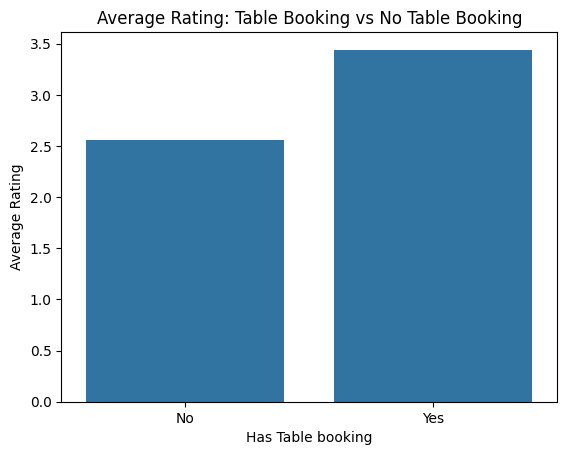

In [5]:
# Average rating: table booking vs no table booking
avg_rating_booking = df.groupby('Has Table booking')['Aggregate rating'].mean()
print(avg_rating_booking)

sns.barplot(x=avg_rating_booking.index, y=avg_rating_booking.values)
plt.ylabel('Average Rating')
plt.title('Average Rating: Table Booking vs No Table Booking')
plt.show()

Has Online delivery         No        Yes
Price range                              
1                    84.225923  15.774077
2                    58.689367  41.310633
3                    70.809659  29.190341
4                    90.955631   9.044369


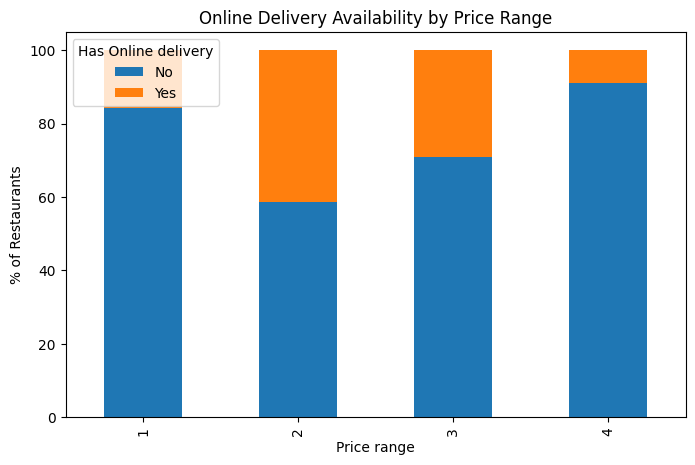

In [6]:
# Online delivery availability across price ranges
delivery_by_price = pd.crosstab(df['Price range'], df['Has Online delivery'], normalize='index') * 100
print(delivery_by_price)

delivery_by_price.plot(kind='bar', stacked=True, figsize=(8,5))
plt.ylabel('% of Restaurants')
plt.title('Online Delivery Availability by Price Range')
plt.show()

Level 2, Task 2: Price Range Analysis

Price range
1    4444
2    3113
3    1408
4     586
Name: count, dtype: int64


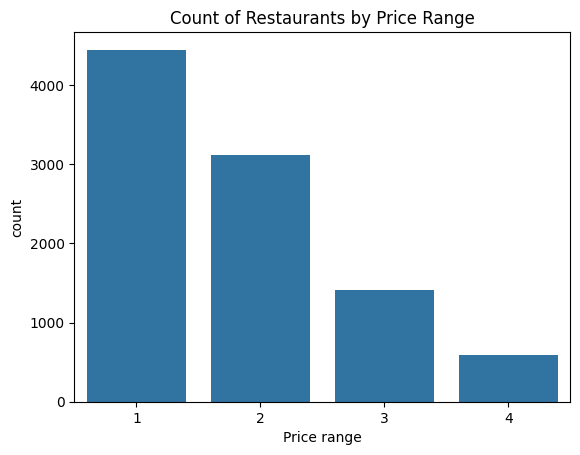

In [7]:
# Most common price range
most_common_price = df['Price range'].value_counts()
print(most_common_price)

sns.countplot(x='Price range', data=df)
plt.title('Count of Restaurants by Price Range')
plt.show()

Price range
1    1.999887
2    2.941054
3    3.683381
4    3.817918
Name: Aggregate rating, dtype: float64


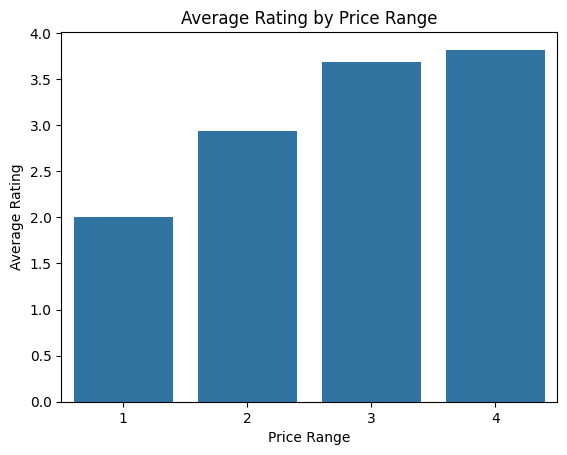

In [8]:
# Average rating for each price range
avg_rating_price = df.groupby('Price range')['Aggregate rating'].mean()
print(avg_rating_price)

sns.barplot(x=avg_rating_price.index, y=avg_rating_price.values)
plt.xlabel('Price Range')
plt.ylabel('Average Rating')
plt.title('Average Rating by Price Range')
plt.show()

In [9]:
# Color representing highest average rating per price range
# 'Rating color' column already exists in the dataset
color_by_price = df.groupby('Price range')['Rating color'].agg(lambda x: x.value_counts().index[0])
print(color_by_price)

# Also confirm which price range has the highest avg rating, and its typical color
highest_price_range = avg_rating_price.idxmax()
print(f"\nPrice range with highest average rating: {highest_price_range}")
print(f"Most common color for that price range: {color_by_price[highest_price_range]}")

Price range
1    Orange
2    Orange
3    Yellow
4    Yellow
Name: Rating color, dtype: object

Price range with highest average rating: 4
Most common color for that price range: Yellow


Level 2, Task 3: Feature Engineering

In [10]:
# Extract length-based features
df['Restaurant Name Length'] = df['Restaurant Name'].apply(len)
df['Address Length'] = df['Address'].apply(len)

df[['Restaurant Name', 'Restaurant Name Length', 'Address', 'Address Length']].head()

,Restaurant Name,Restaurant Name Length,Address,Address Length
0,Le Petit Souffle,16,"Third Floor, Century City Mall, Kalayaan Avenu...",71
1,Izakaya Kikufuji,16,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...",67
2,Heat - Edsa Shangri-La,22,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...",56
3,Ooma,4,"Third Floor, Mega Fashion Hall, SM Megamall, O...",70
4,Sambo Kojin,11,"Third Floor, Mega Atrium, SM Megamall, Ortigas...",64


In [11]:
# Encode categorical Yes/No columns into binary features
df['Has Table Booking'] = df['Has Table booking'].apply(lambda x: 1 if x == 'Yes' else 0)
df['Has Online Delivery'] = df['Has Online delivery'].apply(lambda x: 1 if x == 'Yes' else 0)

df[['Has Table booking', 'Has Table Booking', 'Has Online delivery', 'Has Online Delivery']].head()

,Has Table booking,Has Table Booking,Has Online delivery,Has Online Delivery
0,Yes,1,No,0
1,Yes,1,No,0
2,Yes,1,No,0
3,No,0,No,0
4,Yes,1,No,0


In [12]:
# Quick sanity check — confirm new columns exist and look right
df[['Restaurant Name Length', 'Address Length', 'Has Table Booking', 'Has Online Delivery']].describe()

,Restaurant Name Length,Address Length,Has Table Booking,Has Online Delivery
count,9551.000000,9551.000000,9551.000000,9551.000000
mean,15.209821,53.604544,0.121244,0.256622
std,6.891208,17.209359,0.326428,0.436792
min,2.000000,13.000000,0.000000,0.000000
25%,10.000000,41.000000,0.000000,0.000000
50%,14.000000,52.000000,0.000000,0.000000
75%,19.000000,64.000000,0.000000,1.000000
max,54.000000,132.000000,1.000000,1.000000
